# PCA Embedddings 

In [ ]:
import os
from glob import glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import joblib

import math
import hashlib
from collections import defaultdict, Counter
from pathlib import Path


In [7]:
RANDOM_STATE = 42

DATASET_ROOT = Path(os.environ.get("DATASET_ROOT", "/Volumes/T5 EVO"))
DATASET_PATH = DATASET_ROOT / "hf" / "merrec"

CFG = {
    "max_total_rows": 20_000_000,
    "col_user": "user_id",
    "col_item": "item_id",
    "positive_action": "view",
    "top_k_users": 2_000_000,
    "pca_components": 6,
    "random_state": RANDOM_STATE,
    "batch_size": 65536,
    "output_dir": "pca_outputs"
}

os.makedirs(CFG["output_dir"], exist_ok=True)


In [8]:
import math
import numpy as np
import hashlib
from collections import defaultdict, Counter
import pyarrow.dataset as ds


class StreamingUserFeatureBuilder:
    """
    Production-grade streaming feature builder.

    Builds user-level aggregates:
    - activity intensity
    - session counts
    - price statistics
    - brand/category counters
    - approximate distinct item count (bitmap)

    Designed for large-scale parquet datasets.
    """

    def __init__(self, dataset_path, cfg):
        self.dataset_path = str(dataset_path)
        self.cfg = cfg

        self.bitmap_size = cfg.get("bitmap_size", 2048)
        self.batch_size = cfg.get("batch_size", 65536)

        # Initialize dataset once
        self.dataset = ds.dataset(self.dataset_path, format="parquet")

    # -----------------------------------------------------
    # Hashing utilities
    # -----------------------------------------------------

    def _hash(self, value):
        if value is None:
            value = ""
        if not isinstance(value, str):
            value = str(value)

        h = hashlib.blake2b(value.encode("utf-8"), digest_size=8).digest()
        return int.from_bytes(h, "little") % self.bitmap_size

    def _update_bitmap(self, bitmap_dict, user, value):
        idx = self._hash(value)
        byte_index = idx // 8
        bit_index = idx % 8
        bitmap_dict[user][byte_index] |= (1 << bit_index)

    # -----------------------------------------------------
    # Main build
    # -----------------------------------------------------

    def build(self):

        col_u = self.cfg["col_user"]
        max_total_rows = self.cfg.get("max_total_rows", None)

        scanner = self.dataset.scanner(
            columns=[
                col_u,
                "session_id",
                "price",
                "brand_id",
                "c1_id",
                "item_id"
            ],
            batch_size=self.batch_size
        )

        # User-level aggregates
        user_total = defaultdict(int)
        user_sessions = defaultdict(set)

        user_price_sum = defaultdict(float)
        user_price_sq_sum = defaultdict(float)
        user_price_min = defaultdict(lambda: float("inf"))
        user_price_max = defaultdict(lambda: float("-inf"))

        user_brand_counter = defaultdict(Counter)
        user_cat_counter = defaultdict(Counter)

        user_item_bitmap = defaultdict(
            lambda: bytearray(self.bitmap_size // 8)
        )

        total_rows = 0

        # -------------------------------------------------
        # Streaming loop
        # -------------------------------------------------

        for rb in scanner.to_batches():

            users = rb.column(col_u).to_pylist()
            sessions = rb.column("session_id").to_pylist()
            prices = rb.column("price").to_pylist()
            brands = rb.column("brand_id").to_pylist()
            cats = rb.column("c1_id").to_pylist()
            items = rb.column("item_id").to_pylist()

            for u, s, p, b, c, it in zip(
                users, sessions, prices, brands, cats, items
            ):

                # Proper early stopping
                if max_total_rows and total_rows >= max_total_rows:
                    break

                total_rows += 1

                if u is None:
                    continue

                # ------------------------
                # Activity count
                # ------------------------
                user_total[u] += 1

                # ------------------------
                # Sessions
                # ------------------------
                if s is not None:
                    user_sessions[u].add(s)

                # ------------------------
                # Price stats
                # ------------------------
                if p is not None:
                    user_price_sum[u] += p
                    user_price_sq_sum[u] += p * p
                    user_price_min[u] = min(user_price_min[u], p)
                    user_price_max[u] = max(user_price_max[u], p)

                # ------------------------
                # Brand
                # ------------------------
                if b is not None:
                    user_brand_counter[u][b] += 1

                # ------------------------
                # Category (level 1)
                # ------------------------
                if c is not None:
                    user_cat_counter[u][c] += 1

                # ------------------------
                # Approx distinct items
                # ------------------------
                if it is not None:
                    self._update_bitmap(user_item_bitmap, u, it)

            # Important: break outer loop too
            if max_total_rows and total_rows >= max_total_rows:
                break

        # -------------------------------------------------
        # Return structured dictionary
        # -------------------------------------------------

        return {
            "total": user_total,
            "sessions": user_sessions,
            "price_sum": user_price_sum,
            "price_sq_sum": user_price_sq_sum,
            "price_min": user_price_min,
            "price_max": user_price_max,
            "brand_counter": user_brand_counter,
            "cat_counter": user_cat_counter,
            "item_bitmap": user_item_bitmap,
        }

In [26]:
builder = StreamingUserFeatureBuilder(DATASET_PATH, CFG)

features = builder.build()

print("Users aggregated:", len(features["total"]))

Users aggregated: 315284


In [27]:
class PCAFeatureMatrix:

    @staticmethod
    def _estimate_distinct(bitmap, m):
        zero_bits = 0
        for byte in bitmap:
            zero_bits += 8 - bin(byte).count("1")
        if zero_bits == 0:
            return m
        return -m * math.log(zero_bits / m)

    @staticmethod
    def build(feature_dict, top_k=200_000, bitmap_size=2048):

        user_total = feature_dict["total"]
        user_sessions = feature_dict["sessions"]
        user_price_sum = feature_dict["price_sum"]
        user_price_sq_sum = feature_dict["price_sq_sum"]
        user_price_min = feature_dict["price_min"]
        user_price_max = feature_dict["price_max"]
        user_brand_counter = feature_dict["brand_counter"]
        user_cat_counter = feature_dict["cat_counter"]
        user_item_bitmap = feature_dict["item_bitmap"]

        top_users = sorted(
            user_total.keys(),
            key=lambda u: user_total[u],
            reverse=True
        )[:top_k]

        X = []

        for u in top_users:

            total = user_total[u]
            sessions = len(user_sessions[u])
            avg_per_session = total / sessions if sessions > 0 else 0

            avg_price = user_price_sum[u] / total if total > 0 else 0
            variance = (
                user_price_sq_sum[u] / total - avg_price ** 2
                if total > 0 else 0
            )

            distinct_items = PCAFeatureMatrix._estimate_distinct(
                user_item_bitmap[u], bitmap_size
            )

            brand_entropy = (
                -sum(
                    (cnt / total) * math.log(cnt / total + 1e-12)
                    for cnt in user_brand_counter[u].values()
                )
                if total > 0 else 0
            )

            cat_entropy = (
                -sum(
                    (cnt / total) * math.log(cnt / total + 1e-12)
                    for cnt in user_cat_counter[u].values()
                )
                if total > 0 else 0
            )

            X.append([
                np.log1p(total),
                np.log1p(sessions),
                avg_per_session,
                np.log1p(distinct_items),
                avg_price,
                variance,
                user_price_min[u] if user_price_min[u] != float("inf") else 0,
                user_price_max[u] if user_price_max[u] != float("-inf") else 0,
                len(user_brand_counter[u]),
                brand_entropy,
                len(user_cat_counter[u]),
                cat_entropy,
            ])

        return top_users, np.array(X, dtype=np.float32)

In [28]:
class PCATrainer:

    def __init__(self, n_components=2, random_state=RANDOM_STATE):
        self.scaler = StandardScaler()
        self.pca = PCA(
            n_components=n_components,
            svd_solver="randomized",
            random_state=random_state
        )

    def fit_transform(self, X):

        X_scaled = self.scaler.fit_transform(X)
        Z = self.pca.fit_transform(X_scaled)

        return Z

    def save(self, output_dir):

        os.makedirs(output_dir, exist_ok=True)
        joblib.dump(self.scaler, f"{output_dir}/scaler.pkl")
        joblib.dump(self.pca, f"{output_dir}/pca_model.pkl")

In [29]:
top_users, X = PCAFeatureMatrix.build(
    features,
    top_k=CFG["top_k_users"],
    bitmap_size=CFG.get("bitmap_size", 4096)
)

# Save feature matrix for downstream notebooks (05_TCNE, etc.)
np.save(os.path.join(CFG["output_dir"], "feature_matrix_X.npy"), X)
np.save(os.path.join(CFG["output_dir"], "user_ids.npy"), np.array(top_users))
print(f"Saved feature_matrix_X.npy: {X.shape}")


Saved feature_matrix_X.npy: (315284, 12)


In [30]:
trainer = PCATrainer(
    n_components=CFG["pca_components"],
    random_state=CFG["random_state"]
)

Z = trainer.fit_transform(X)

print("Shape:", Z.shape)
print("Explained variance ratio:", trainer.pca.explained_variance_ratio_)
print("Total explained:", trainer.pca.explained_variance_ratio_.sum())

Shape: (315284, 6)
Explained variance ratio: [0.4731245  0.19136138 0.09469348 0.07311507 0.06572597 0.03475704]
Total explained: 0.9327774


In [31]:
print(trainer.pca.components_)

[[ 0.39047918  0.36519623  0.200264    0.3453136  -0.04143598  0.03605279
  -0.1166727   0.20758581  0.33855373  0.35546318  0.37848154  0.33296934]
 [-0.01768497  0.01345614 -0.05561864  0.02104116  0.62213147  0.4635706
   0.42328453  0.45921737  0.00350976 -0.03505395 -0.00651628 -0.05187602]
 [-0.0849854  -0.08238459  0.08771727  0.33673036  0.13543384 -0.5057261
   0.5735213  -0.23934853  0.3445598  -0.14552808  0.17524979 -0.18433905]
 [-0.02151995 -0.36997616  0.8981057   0.00710166 -0.00096875  0.17255479
  -0.08449088  0.00866712  0.04602507 -0.02588247 -0.07824186 -0.10055061]
 [ 0.19034767  0.08111673  0.2073187  -0.43164486  0.19107728 -0.31590036
   0.35572547 -0.14318366 -0.3874943   0.31711692 -0.08293045  0.43237874]
 [-0.3778938  -0.40012288 -0.1479502  -0.08500945  0.03224773  0.31174076
   0.02892422 -0.33321914  0.23635414  0.08293387  0.34669334  0.524357  ]]


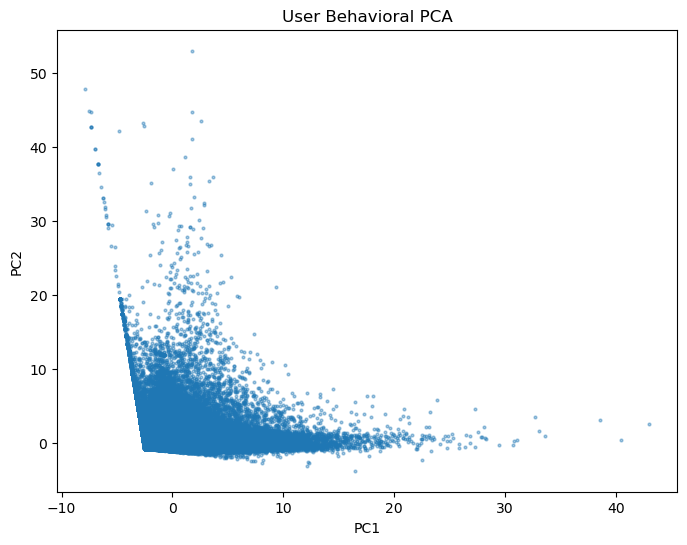

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], s=4, alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("User Behavioral PCA")
plt.show()

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(Z)

In [33]:
df = pd.DataFrame({
    "log_total": X[:,0],
    "distinct_est": X[:,1],
    "diversity_ratio": X[:,2],
    "cluster": clusters
})

print(df.groupby("cluster").mean())

         log_total  distinct_est  diversity_ratio
cluster                                          
0         3.178855      1.976801         4.848171
1         1.346385      0.928066         2.211032
2         6.715469      4.514122        11.615426
3         2.910941      1.927183         3.885170
4         0.897338      0.760939         1.376995
5         5.002809      3.417521         6.199328


In [34]:
import pandas as pd

df_save = pd.DataFrame({
    "user_id": top_users,
    "pc1": Z[:, 0],
    "pc2": Z[:, 1],
    "cluster": clusters
})

df_save.to_csv(
    os.path.join(CFG["output_dir"], "user_pca_clusters.csv"),
    index=False
)

np.save(
    os.path.join(CFG["output_dir"], "pca_coordinates.npy"),
    Z
)

Save Models (Critical)

In [35]:
joblib.dump(
    trainer.pca,
    os.path.join(CFG["output_dir"], "pca_model.pkl")
)

joblib.dump(
    trainer.scaler,
    os.path.join(CFG["output_dir"], "scaler.pkl")
)
joblib.dump(
    kmeans,
    os.path.join(CFG["output_dir"], "kmeans_model.pkl")
)


['pca_outputs/kmeans_model.pkl']

Save Cluster Assignments

In [36]:
np.save(
    os.path.join(CFG["output_dir"], "user_clusters.npy"),
    clusters
)

In [37]:
# Load model
kmeans_path = os.path.join(CFG["output_dir"], "kmeans_model.pkl")
kmeans = joblib.load(kmeans_path)

print("Clusters:", kmeans.n_clusters)

Clusters: 6


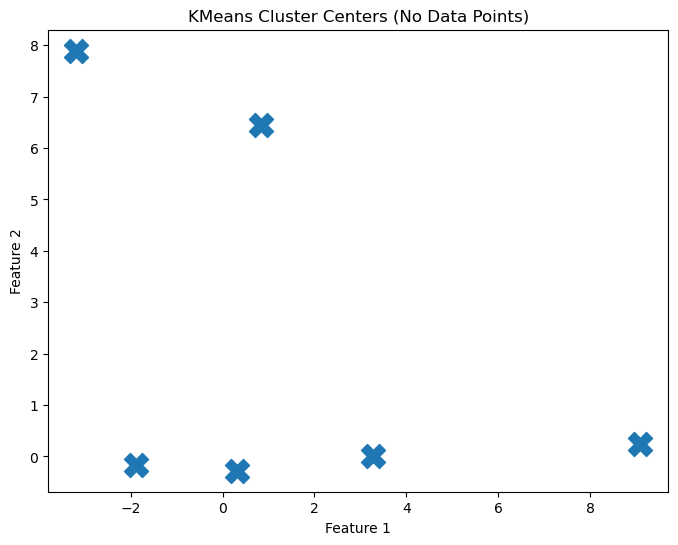

In [26]:
import joblib
import matplotlib.pyplot as plt
import os

kmeans = joblib.load(os.path.join(CFG["output_dir"], "kmeans_model.pkl"))
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8,6))
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, marker='X')
plt.title("KMeans Cluster Centers (No Data Points)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [38]:
# NOTE: tsne_embeddings.npy is produced by 05_TCNE.ipynb.
# Run notebook 05 first, then re-run this cell.
try:
    X_2d = np.load(os.path.join(CFG["output_dir"], "tsne_embeddings.npy"))
    print("Loaded t-SNE embeddings:", X_2d.shape)
except FileNotFoundError:
    import warnings
    warnings.warn("tsne_embeddings.npy not found — run 05_TCNE.ipynb first to generate it.")
    X_2d = None


/var/folders/l1/8rxhw98d6sx08mmf0tt7fsgh0000gn/T/ipykernel_27790/2195872402.py:8: UserWarning: tsne_embeddings.npy not found — run 05_TCNE.ipynb first to generate it.
  warnings.warn("tsne_embeddings.npy not found — run 05_TCNE.ipynb first to generate it.")


In [39]:
FEATURE_NAMES = [
    "log_total_events",
    "log_num_sessions",
    "avg_events_per_session",
    "log_distinct_items",
    "avg_price",
    "price_variance",
    "min_price",
    "max_price",
    "num_unique_brands",
    "brand_entropy",
    "num_unique_categories",
    "category_entropy",
]

OUTPUT_DIR = CFG["output_dir"]

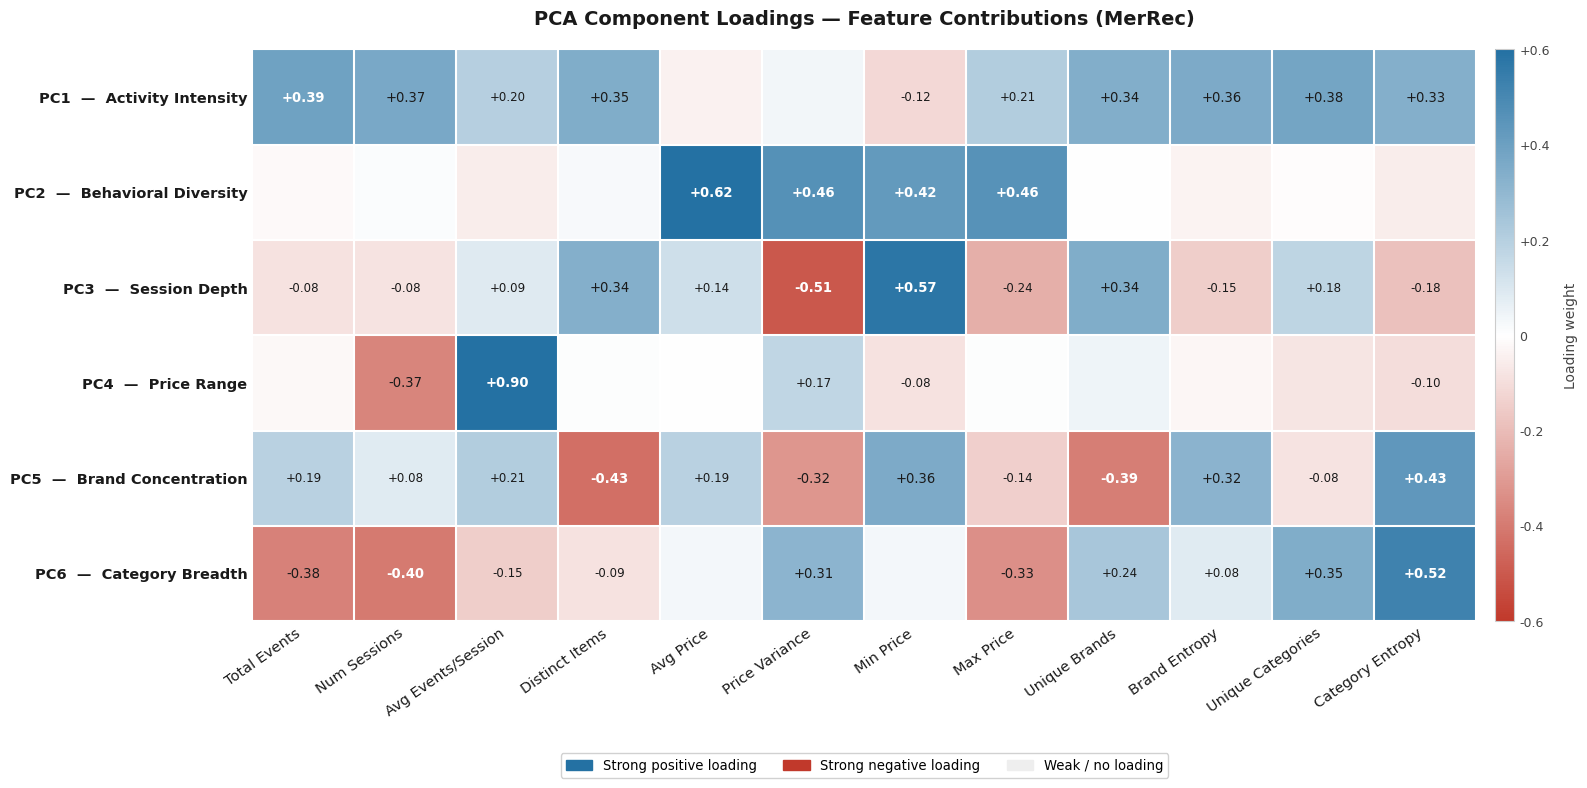

In [43]:
# ── PCA Loadings Heatmap (redesigned) ────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

n_components  = trainer.pca.n_components_
components_df = pd.DataFrame(
    trainer.pca.components_,
    index=[f"PC{i+1}" for i in range(n_components)],
    columns=FEATURE_NAMES,
)

# Cleaner feature name labels
feature_labels = {
    "log_total_events":      "Total Events",
    "log_num_sessions":      "Num Sessions",
    "avg_events_per_session":"Avg Events/Session",
    "log_distinct_items":    "Distinct Items",
    "avg_price":             "Avg Price",
    "price_variance":        "Price Variance",
    "min_price":             "Min Price",
    "max_price":             "Max Price",
    "num_unique_brands":     "Unique Brands",
    "brand_entropy":         "Brand Entropy",
    "num_unique_categories": "Unique Categories",
    "category_entropy":      "Category Entropy",
}
clean_cols = [feature_labels.get(c, c) for c in FEATURE_NAMES]

# PC role labels
pc_roles = [
    "Activity Intensity",
    "Behavioral Diversity",
    "Session Depth",
    "Price Range",
    "Brand Concentration",
    "Category Breadth",
]
pc_labels = [f"PC{i+1}  —  {pc_roles[i]}"
             if i < len(pc_roles) else f"PC{i+1}"
             for i in range(n_components)]

# Color map — clean diverging
cmap = LinearSegmentedColormap.from_list(
    "clean_div", ["#C1392B", "#FFFFFF", "#2471A3"], N=256)

fig, ax = plt.subplots(figsize=(16, n_components * 1.1 + 1.5))
fig.patch.set_facecolor("white")

im = ax.imshow(components_df.values,
               cmap=cmap, vmin=-0.6, vmax=0.6,
               aspect="auto")

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(clean_cols, rotation=35, ha="right",
                   fontsize=10.5, color="#1A1A1A")

ax.set_yticks(range(n_components))
ax.set_yticklabels(pc_labels, fontsize=10.5,
                   color="#1A1A1A", fontweight="bold")

ax.tick_params(axis="both", length=0)

# ── Cell annotations ──────────────────────────────────────────────────────────
for i in range(n_components):
    for j in range(len(FEATURE_NAMES)):
        val      = components_df.values[i, j]
        abs_val  = abs(val)

        # Only annotate cells with meaningful loadings
        if abs_val < 0.08:
            txt      = ""
        else:
            txt      = f"{val:+.2f}"

        txt_color = "white" if abs_val > 0.38 else "#1A1A1A"
        weight    = "bold"  if abs_val > 0.38 else "normal"
        size      = 9.5     if abs_val > 0.25 else 8.5

        if txt:
            ax.text(j, i, txt,
                    ha="center", va="center",
                    fontsize=size, color=txt_color,
                    fontweight=weight)

# ── Grid lines between cells ──────────────────────────────────────────────────
for x in np.arange(-0.5, len(FEATURE_NAMES), 1):
    ax.axvline(x, color="white", linewidth=1.5)
for y in np.arange(-0.5, n_components, 1):
    ax.axhline(y, color="white", linewidth=1.5)

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar = plt.colorbar(im, ax=ax, pad=0.015,
                    fraction=0.018, aspect=30)
cbar.set_label("Loading weight", color="#444444",
               fontsize=10, labelpad=10)
cbar.ax.tick_params(colors="#444444", labelsize=9, length=0)
cbar.outline.set_edgecolor("#CCCCCC")

# Colorbar tick labels
cbar.set_ticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
cbar.set_ticklabels(["-0.6", "-0.4", "-0.2", "0",
                     "+0.2", "+0.4", "+0.6"])

# ── Legend for interpretation ─────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color="#2471A3", label="Strong positive loading"),
    mpatches.Patch(color="#C1392B", label="Strong negative loading"),
    mpatches.Patch(color="#EEEEEE", label="Weak / no loading"),
]
ax.legend(handles=legend_elements,
          loc="upper center",
          bbox_to_anchor=(0.5, -0.22),
          ncol=3, fontsize=9.5,
          framealpha=0.9,
          edgecolor="#CCCCCC")

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title(
    "PCA Component Loadings — Feature Contributions (MerRec)",
    fontsize=14, fontweight="bold", pad=18, color="#1A1A1A"
)

ax.set_facecolor("white")
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pca_loadings_heatmap.png"),
            dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

In [44]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

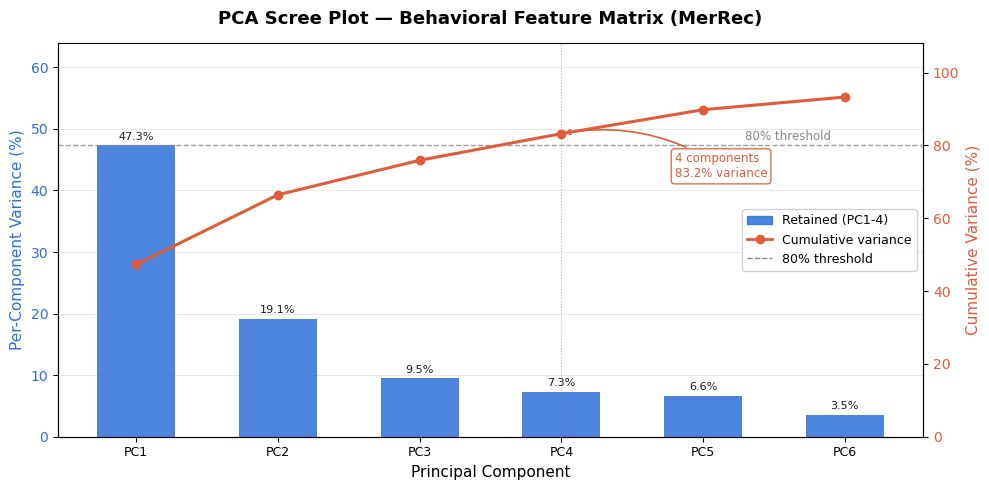

Total variance explained by 6 components: 93.3%


In [45]:
# ── PCA Scree Plot ────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

evr        = trainer.pca.explained_variance_ratio_
cumulative = np.cumsum(evr)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bar_colors = ["#2E6FD9" if i < n_components else "#CCCCCC"
              for i in range(len(evr))]
bars = ax1.bar(range(1, len(evr) + 1), evr * 100,
               color=bar_colors, alpha=0.85, width=0.55,
               zorder=3, label="Per component")

ax1.set_ylabel("Per-Component Variance (%)", color="#2E6FD9", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#2E6FD9")
ax1.set_ylim(0, evr.max() * 100 * 1.35)
ax1.set_xlabel("Principal Component", fontsize=11)
ax1.set_xticks(range(1, len(evr) + 1))
ax1.set_xticklabels([f"PC{i}" for i in range(1, len(evr) + 1)], fontsize=9)

ax2.plot(range(1, len(evr) + 1), cumulative * 100,
         color="#E05C3A", linewidth=2.2, marker="o",
         markersize=6, zorder=4, label="Cumulative")
ax2.set_ylabel("Cumulative Variance (%)", color="#E05C3A", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#E05C3A")
ax2.set_ylim(0, 108)

threshold_pct = 80
ax2.axhline(threshold_pct, color="#888888", linewidth=1.0,
            linestyle="--", alpha=0.8)
ax2.text(len(evr) - 0.1, threshold_pct + 1.5,
         f"{threshold_pct}% threshold",
         ha="right", fontsize=8.5, color="#888888")

n_at_threshold = np.searchsorted(cumulative, threshold_pct / 100) + 1
ax2.axvline(n_at_threshold, color="#888888", linewidth=0.8,
            linestyle=":", alpha=0.6)

for bar, val in zip(bars, evr * 100):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             val + evr.max() * 100 * 0.02,
             f"{val:.1f}%",
             ha="center", fontsize=8, color="#1A1A1A")

cum_at_threshold = cumulative[n_at_threshold - 1] * 100
ax2.annotate(
    f"{n_at_threshold} components\n{cum_at_threshold:.1f}% variance",
    xy=(n_at_threshold, cum_at_threshold),
    xytext=(n_at_threshold + 0.8, cum_at_threshold - 12),
    fontsize=8.5, color="#E05C3A",
    arrowprops=dict(arrowstyle="->", color="#E05C3A",
                    lw=1.2, connectionstyle="arc3,rad=0.2"),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="#E05C3A", alpha=0.9)
)

ax1.set_title("PCA Scree Plot — Behavioral Feature Matrix (MerRec)",
              fontsize=13, fontweight="bold", pad=14)
ax1.set_facecolor("white")
fig.patch.set_facecolor("white")
ax1.spines["top"].set_visible(False)
ax1.yaxis.grid(True, color="#E8E8E8", linewidth=0.7)
ax1.set_axisbelow(True)

retained_patch = mpatches.Patch(color="#2E6FD9", alpha=0.85,
                                 label=f"Retained (PC1-{n_at_threshold})")
cum_line = Line2D([0], [0], color="#E05C3A", linewidth=2,
                  marker="o", label="Cumulative variance")
thr_line = Line2D([0], [0], color="#888888", linewidth=1.0,
                  linestyle="--", label=f"{threshold_pct}% threshold")
ax1.legend(handles=[retained_patch, cum_line, thr_line],
           loc="center right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pca_scree_plot.png"),
            dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Total variance explained by {n_components} components: "
      f"{cumulative[n_components-1]*100:.1f}%")


CLUSTER VALIDATION METRICS
  Silhouette score      : 0.3453  (higher is better, max 1.0)
  Davies-Bouldin index  : 0.9812  (lower is better, min 0.0)

Searching optimal k (this may take ~1 min) ...
  k=2  silhouette=0.4235  DB=1.0749
  k=3  silhouette=0.3740  DB=1.0425
  k=4  silhouette=0.3914  DB=0.9924
  k=5  silhouette=0.3396  DB=1.0339
  k=6  silhouette=0.3445  DB=0.9796
  k=7  silhouette=0.3550  DB=0.9085
  k=8  silhouette=0.3097  DB=0.9744
  k=9  silhouette=0.3174  DB=0.9261
  k=10  silhouette=0.2894  DB=0.9641


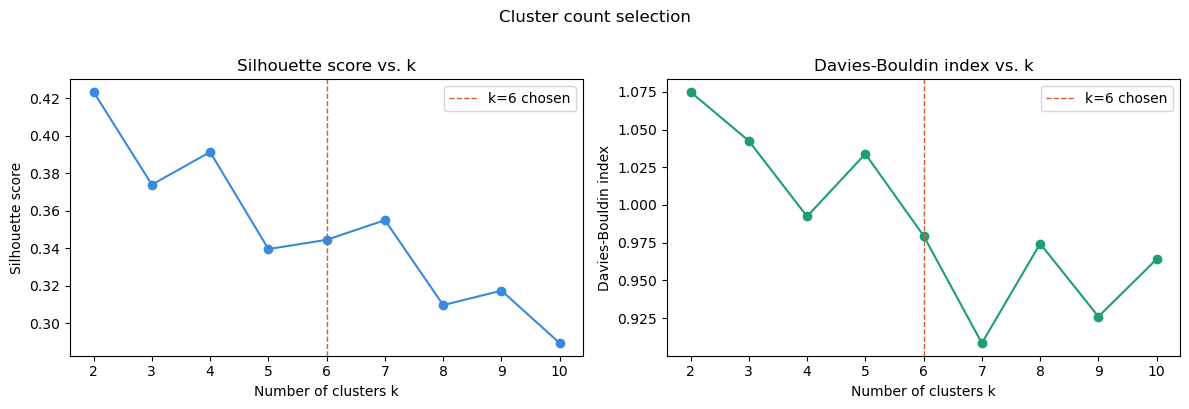

In [39]:
print("\n" + "=" * 60)
print("CLUSTER VALIDATION METRICS")
print("=" * 60)
 
sil = silhouette_score(Z, clusters, sample_size=20_000, random_state=42)
db  = davies_bouldin_score(Z, clusters)
 
print(f"  Silhouette score      : {sil:.4f}  (higher is better, max 1.0)")
print(f"  Davies-Bouldin index  : {db:.4f}  (lower is better, min 0.0)")
 
# ── Silhouette vs k — justify the choice of k=6 ──
k_range = range(2, 11)
sil_scores = []
db_scores  = []
 
print("\nSearching optimal k (this may take ~1 min) ...")
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(Z), size=min(50_000, len(Z)), replace=False)
Z_sample = Z[sample_idx]
 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    labels = km.fit_predict(Z_sample)
    sil_scores.append(silhouette_score(Z_sample, labels, sample_size=10_000, random_state=42))
    db_scores.append(davies_bouldin_score(Z_sample, labels))
    print(f"  k={k}  silhouette={sil_scores[-1]:.4f}  DB={db_scores[-1]:.4f}")
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
ax1.plot(list(k_range), sil_scores, "o-", color="#378ADD")
ax1.axvline(6, color="#D85A30", linestyle="--", linewidth=1, label="k=6 chosen")
ax1.set_xlabel("Number of clusters k")
ax1.set_ylabel("Silhouette score")
ax1.set_title("Silhouette score vs. k")
ax1.legend()
 
ax2.plot(list(k_range), db_scores, "o-", color="#1D9E75")
ax2.axvline(6, color="#D85A30", linestyle="--", linewidth=1, label="k=6 chosen")
ax2.set_xlabel("Number of clusters k")
ax2.set_ylabel("Davies-Bouldin index")
ax2.set_title("Davies-Bouldin index vs. k")
ax2.legend()
 
plt.suptitle("Cluster count selection", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_k_selection.png"), dpi=150, bbox_inches="tight")
plt.show()


CLUSTER MEAN FEATURE PROFILES
         log_total_events  log_num_sessions  avg_events_per_session  log_distinct_items   avg_price  price_variance   min_price    max_price  num_unique_brands  brand_entropy  num_unique_categories  category_entropy
cluster                                                                                                                                                                                                                
0                   0.904             0.762                   1.394               7.953  864.458984    20505.210938  807.541992   925.700012           1.170000          0.095               1.130000             0.076
1                   3.202             1.994                   4.866               7.969   67.348000    10022.167969    9.797000   298.256989           8.251000          1.541               6.970000             1.377
2                   1.357             0.933                   2.228               7.954   72.527000     3

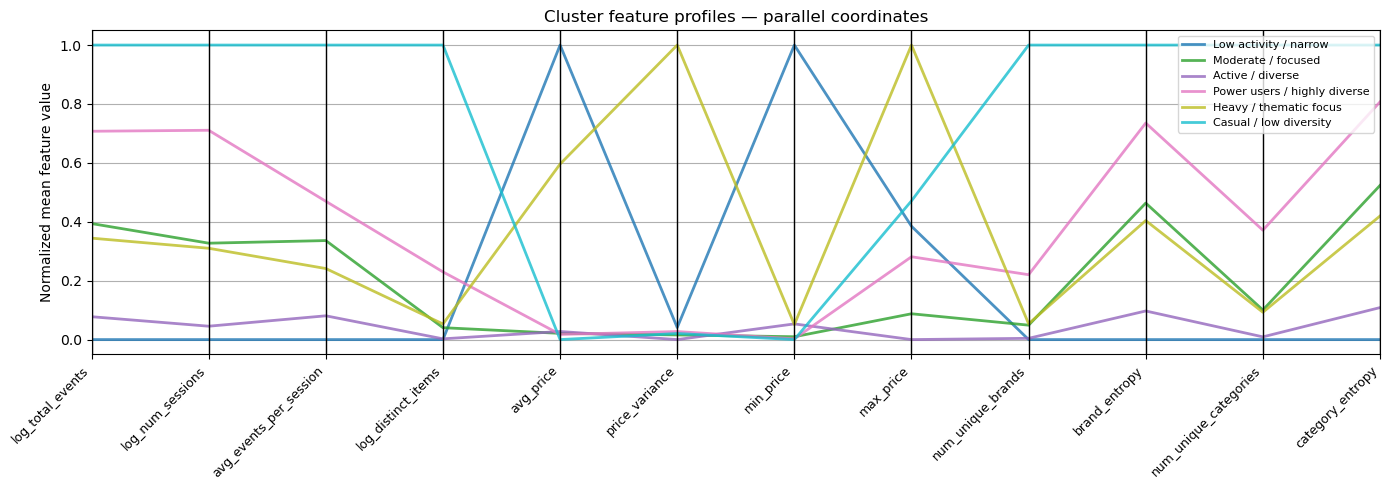

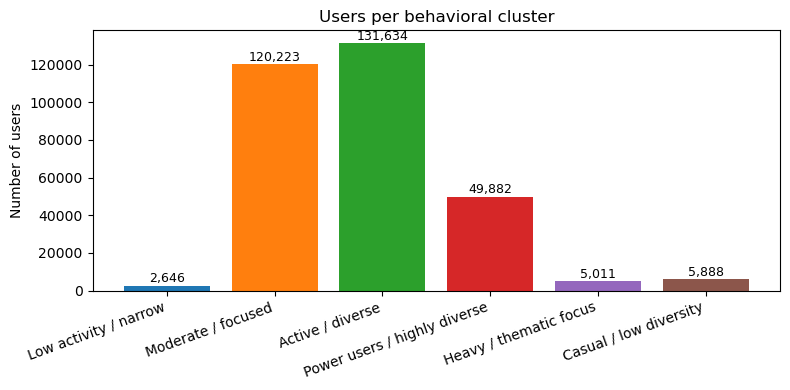

In [32]:
df_features = pd.DataFrame(X, columns=FEATURE_NAMES)
df_features["cluster"] = clusters
 
cluster_profile = df_features.groupby("cluster")[FEATURE_NAMES].mean().round(3)
 
print("\n" + "=" * 60)
print("CLUSTER MEAN FEATURE PROFILES")
print("=" * 60)
print(cluster_profile.to_string())
 
# Map back to interpretable names based on profile
cluster_labels = {
    0: "Low activity / narrow",
    1: "Moderate / focused",
    2: "Active / diverse",
    3: "Power users / highly diverse",
    4: "Heavy / thematic focus",
    5: "Casual / low diversity",
}
 
# ── Radar / parallel coordinates plot ──
from pandas.plotting import parallel_coordinates
 
# Normalize features to [0,1] for radar
profile_norm = (cluster_profile - cluster_profile.min()) / \
               (cluster_profile.max() - cluster_profile.min() + 1e-9)
profile_norm["cluster"] = [cluster_labels.get(i, f"Cluster {i}") for i in profile_norm.index]
 
fig, ax = plt.subplots(figsize=(14, 5))
parallel_coordinates(profile_norm, "cluster", ax=ax, colormap="tab10", alpha=0.8, linewidth=2)
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Normalized mean feature value")
ax.set_title("Cluster feature profiles — parallel coordinates")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_parallel_coords.png"), dpi=150, bbox_inches="tight")
plt.show()
 
# ── Cluster size bar chart ──
cluster_counts = pd.Series(clusters).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [cluster_labels.get(i, f"Cluster {i}") for i in cluster_counts.index],
    cluster_counts.values,
    color=plt.cm.tab10(range(len(cluster_counts)))
)
for bar, count in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f"{count:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Number of users")
ax.set_title("Users per behavioral cluster")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_sizes.png"), dpi=150, bbox_inches="tight")
plt.show()

In [33]:
from sklearn.metrics import adjusted_rand_score
 
seeds = [42, 123, 456, 789, 1024]
base_labels = KMeans(n_clusters=6, random_state=seeds[0], n_init=10).fit_predict(Z)
ari_scores = []
 
print("\n" + "=" * 60)
print("STABILITY CHECK (Adjusted Rand Index across seeds)")
print("=" * 60)
 
for seed in seeds[1:]:
    km_s = KMeans(n_clusters=6, random_state=seed, n_init=10)
    labels_s = km_s.fit_predict(Z)
    ari = adjusted_rand_score(base_labels, labels_s)
    ari_scores.append(ari)
    print(f"  seed={seed}  ARI vs seed={seeds[0]}: {ari:.4f}")
 
print(f"\n  Mean ARI : {np.mean(ari_scores):.4f}")
print(f"  Std  ARI : {np.std(ari_scores):.4f}")
print("  (ARI=1.0 = identical assignment; >0.8 = stable)")
 


STABILITY CHECK (Adjusted Rand Index across seeds)
  seed=123  ARI vs seed=42: 0.9824
  seed=456  ARI vs seed=42: 0.9808
  seed=789  ARI vs seed=42: 0.9869
  seed=1024  ARI vs seed=42: 0.9850

  Mean ARI : 0.9838
  Std  ARI : 0.0023
  (ARI=1.0 = identical assignment; >0.8 = stable)


In [38]:

summary = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(n_components)],
    "explained_variance_pct": (evr * 100).round(2),
    "cumulative_pct": (cumulative * 100).round(2),
})
summary.to_csv(os.path.join(OUTPUT_DIR, "pca_variance_summary.csv"), index=False)
 
cluster_profile.to_csv(os.path.join(OUTPUT_DIR, "cluster_feature_profiles.csv"))
 
metrics_df = pd.DataFrame({
    "metric": ["silhouette_score", "davies_bouldin_index", "mean_ARI_stability", "std_ARI_stability"],
    "value": [round(sil, 4), round(db, 4), round(float(np.mean(ari_scores)), 4), round(float(np.std(ari_scores)), 4)]
})
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "validation_metrics.csv"), index=False)
 
print("\nAll outputs saved to:", OUTPUT_DIR)
print("Files: pca_loadings_heatmap.png, pca_scree_plot.png,")
print("       cluster_k_selection.png, cluster_parallel_coords.png,")
print("       cluster_sizes.png, pca_variance_summary.csv,")
print("       cluster_feature_profiles.csv, validation_metrics.csv")
 


All outputs saved to: pca_outputs
Files: pca_loadings_heatmap.png, pca_scree_plot.png,
       cluster_k_selection.png, cluster_parallel_coords.png,
       cluster_sizes.png, pca_variance_summary.csv,
       cluster_feature_profiles.csv, validation_metrics.csv
